#**Scenario 1**
---
##**TL-MobileNetV2 - Optimizer Adam - Learning Rate 0.001 - Object Cropping Dataset**

###**Import Dataset**

In [ ]:
#--- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#--- Import Dataset Ori ---
dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/original_dataset/dataset_object_cropping' # lokasi dataset

import os
if os.path.exists(dataset_path):
    print("Dataset ditemukan di:", dataset_path)
else:
    print("Folder dataset tidak ditemukan, cek kembali path-nya.")

Dataset ditemukan di: /content/drive/MyDrive/SKRIPSI/dataset/original_dataset/dataset_object_cropping


In [ ]:
#--- Cek Jumlah Data Per Kelas ---
import os

dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/original_dataset/dataset_object_cropping'  # lokasi dataset

total_files = 0

print("Jumlah data per kelas:\n")

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith('.jpg')
        ]
        num_files = len(files)
        total_files += num_files

        print(f"{class_name}: {num_files} data")

print("\nTotal seluruh data:", total_files)

Jumlah data per kelas:

pisang cavendish: 50 data
pisang mas: 50 data
pisang susu: 50 data
pisang embug: 50 data
pisang candi: 50 data
pisang barlin: 50 data
pisang ambon: 50 data
pisang agung: 50 data

Total seluruh data: 400


In [ ]:
#--- Display Dataset ---
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/original_dataset/dataset_object_cropping' # lokasi dataset

# Ambil daftar kelas (subfolder)
classes = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])

# Setup figure: 2 baris x 4 kolom
plt.figure(figsize=(16, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    # Ambil satu gambar pertama dari kelas tersebut
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith('.jpg')
    ]

    if len(images) == 0:
        continue

    img_path = os.path.join(class_path, images[0])
    img = Image.open(img_path)

    # Plot
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

###**Preprocessing Dataset**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, AveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
train_dir = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_object_cropping/train'
val_dir = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_object_cropping/val'

In [ ]:
#--- Preprocessing Dataset ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input # Normalisasi [-1, 1]
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2560 images belonging to 8 classes.
Found 640 images belonging to 8 classes.


###**Pemodelan Arsitektur MobileNetV2**

In [ ]:
#--- Load MobileNetV2 (Pretrained ImageNet) ---
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze semua layer base model
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#-- Penambahan Head Custom Layer --

# Tambahkan custom classifier di akhir
x = base_model.output
x = AveragePooling2D(pool_size=(7, 7))(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

###**Compile dengan Optimizer Adam dan Learning Rate 0.001**

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

###**Training Model**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#--- Early Stopping untuk mencegah overfitting ---
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0.001,
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

#--- Model Check Point untuk menyimpan model terbaik ---
checkpoint = ModelCheckpoint(
    'best_model_mobilenetv2.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

In [ ]:
#--- Training model ---
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 833s 10s/step - accuracy: 0.7473 - loss: 0.7764 - val_accuracy: 0.9953 - val_loss: 0.0344
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.9919 - loss: 0.0438 - val_accuracy: 0.9969 - val_loss: 0.0131
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.9951 - loss: 0.0250 - val_accuracy: 0.9984 - val_loss: 0.0073
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.9946 - loss: 0.0192 - val_accuracy: 0.9953 - val_loss: 0.0150
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.9988 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0

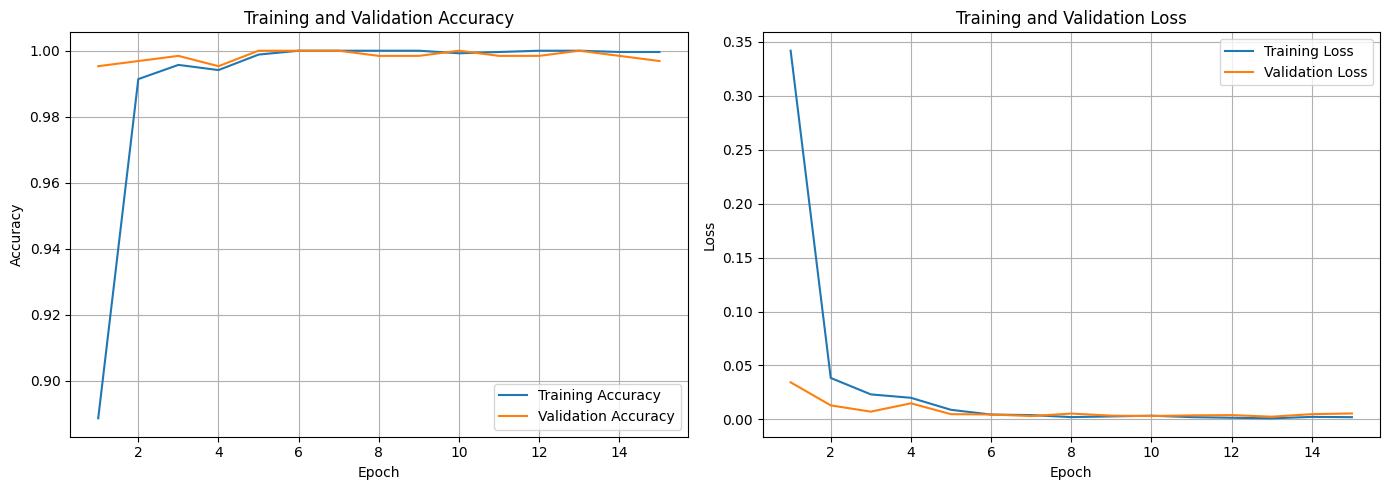

In [ ]:
#--- Menampilkan Grafik Akurasi dan Loss ---
import matplotlib.pyplot as plt

# Ambil data dari history
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(accuracy) + 1)

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

###**Confussion Matrix**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Prediksi kelas
y_pred_prob = model.predict(val_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Label sebenarnya
y_true = val_generator.classes

# Nama kelas
class_names = list(val_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step


In [ ]:
cm = confusion_matrix(y_true, y_pred)

<Figure size 800x800 with 0 Axes>

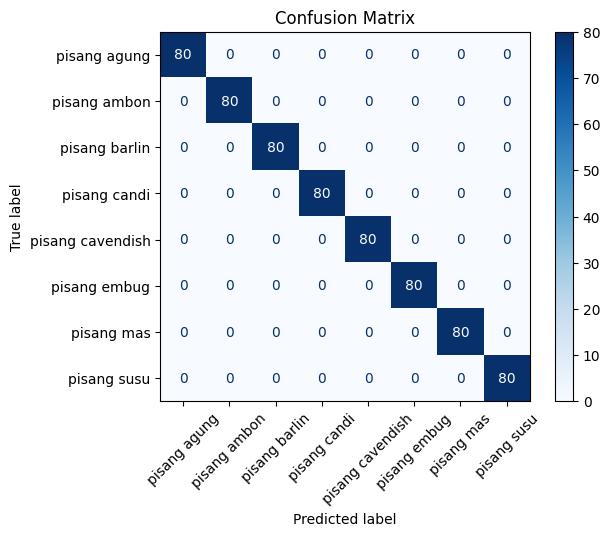

In [ ]:
plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

###**Precision, Recall, dan F1-Score**

In [ ]:
from sklearn.metrics import classification_report

# Tampilkan classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)

Classification Report:

                  precision    recall  f1-score   support

    pisang agung     1.0000    1.0000    1.0000        80
    pisang ambon     1.0000    1.0000    1.0000        80
   pisang barlin     1.0000    1.0000    1.0000        80
    pisang candi     1.0000    1.0000    1.0000        80
pisang cavendish     1.0000    1.0000    1.0000        80
    pisang embug     1.0000    1.0000    1.0000        80
      pisang mas     1.0000    1.0000    1.0000        80
     pisang susu     1.0000    1.0000    1.0000        80

        accuracy                         1.0000       640
       macro avg     1.0000    1.0000    1.0000       640
    weighted avg     1.0000    1.0000    1.0000       640



#**Heatmap**

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
#--- Load & Pre-process Image ---
def load_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img, img_array

In [ ]:
#--- Grad-CAM ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):

    grad_model = Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
#--- Overlay Heatmap ---
def overlay_heatmap(heatmap, original_img, alpha=0.4):
    heatmap = cv2.resize(
        heatmap,
        (original_img.size[0], original_img.size[1])
    )

    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    original_img = np.array(original_img)
    superimposed_img = heatmap * alpha + original_img

    return np.uint8(superimposed_img)

In [ ]:
import matplotlib.pyplot as plt

# Image Paths (8 citra)
img_paths = [
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/testing_no_background/pisang agung.jpg", #-- sesuaikan
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/testing_no_background/pisang candi.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/testing_no_background/pisang barlin.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/testing_no_background/pisang mas.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/testing_no_background/pisang cavendish.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/testing_no_background/pisang ambon.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/testing_no_background/pisang embug.jpg",
    "/content/drive/MyDrive/SKRIPSI/dataset/dataset testing/testing_no_background/pisang susu.jpg"
]

# Nama layer konvolusi terakhir
last_conv_layer_name = "out_relu"

plt.figure(figsize=(16, 8))

for i, img_path in enumerate(img_paths):
    # Load 1 image
    original_img, img_array = load_image(img_path)

    # Generate Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    # Overlay heatmap ke gambar asli
    superimposed_img = overlay_heatmap(heatmap, original_img)

    # Tampilkan
    plt.subplot(2, 4, i + 1)
    plt.imshow(superimposed_img)
    plt.axis("off")
    plt.title(f"Gambar {i+1}")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

###**Simpan Model dalam Format .h5**

In [ ]:
from google.colab import files

model.save('[S6] S1_TL-MobileNetV2.h5')
files.download('[S6] S1_TL-MobileNetV2.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Prediction**

In [ ]:
#--- Import Model .h5 ---
from google.colab import files
uploaded = files.upload()

Saving [S6] S1_TL-MobileNetV2.h5 to [S6] S1_TL-MobileNetV2.h5


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

#--- Upload Multiple Images ---
def upload_images():
    uploaded = files.upload()
    image_paths = list(uploaded.keys())
    return image_paths

#--- Preprocess Image ---
def preprocess_image(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

#--- Predict Image ---
def predict_image(model, image_array, class_names):
    predictions = model.predict(image_array)
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions)
    return predictions[0], predicted_class, confidence

#--- Class Names ---
class_names = [
    'pisang_agung',
    'pisang_ambon',
    'pisang_barlin',
    'pisang_candi',
    'pisang_cavendish',
    'pisang_embug',
    'pisang_mas',
    'pisang_susu'
]

#--- Load Model ---
model_path = '/content/[S6] S1_TL-MobileNetV2.h5' #sesuaikan path
model = tf.keras.models.load_model(model_path)

#--- Upload Images ---
image_paths = upload_images()

#--- Loop Prediction ---
for image_path in image_paths:

    image_array = preprocess_image(image_path)
    predictions, predicted_class, confidence = predict_image(
        model, image_array, class_names
    )

    print("\n==============================")
    print(f"Image : {image_path}")
    print("=== HASIL PREDIKSI ===")

    for i, class_name in enumerate(class_names):
        print(f"{class_name}: {predictions[i] * 100:.2f}%")

    print(f"\nPrediksi Akhir : {predicted_class}")
    print(f"Confidence     : {confidence * 100:.2f}%")

    #--- Display Image ---
    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(f"{predicted_class} ({confidence * 100:.2f}%)")
    plt.axis('off')
    plt.show()

Output hidden; open in https://colab.research.google.com to view.